In [1]:
import pandas as pd
import math
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
def load_data():
    df_stock = pd.read_csv('./Data/Fama_French/stock_daily_data.csv')
    df_stock['date'] = pd.to_datetime(df_stock['date'])
    df_1a_mean = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')
    df_7_min = pd.read_csv('./Data/Fama_French/risk_scores_item_7_sum.csv')
    df_score = pd.merge(df_1a_mean, df_7_min,
                    on=['year', 'ticker'],
                    suffixes=('_1a', '_7'),
                    how='inner')
    df_score.dropna()
    return df_stock, df_score

In [2]:
def construct_portfolio(df_stock, df_score, split_num=20, bool_print=True, action=0.25, no_action=0.75):

    rebalance_years = sorted(df_score['year'].unique())
    all_portfolio_returns = []
    for year in rebalance_years:
        df_year = df_score[df_score['year'] == year].copy()

        df_year_action = df_year[df_year['risk_score_7'] <= df_year['risk_score_7'].quantile(action)]
        df_year_no_action = df_year[df_year['risk_score_7'] > df_year['risk_score_7'].quantile(no_action)]
        # print(df_year['risk_score_7'].quantile(0.75))
        # print(df_year['risk_score_7'].quantile(0.25))

        # print(df_year['risk_score_7'].mean())

        # print(df_year_action.describe())
        # print(f"Processing year: {year}")
        # print(df_year_action)
        # print(df_year_no_action)




        min_split_number_action =  split_num if len(df_year_action) > 2 * split_num else math.floor(len(df_year_action) / 2)
        min_split_number_no_action = split_num if len(df_year_no_action) > 2 * split_num else math.floor(len(df_year_no_action) / 2)

        # min_split_number = min_split_number_no_action if min_split_number_action > min_split_number_no_action else min_split_number_action
        # min_split_number_action = min_split_number
        # min_split_number_no_action = min_split_number

        portfolio_action_high_risk = df_year_action[:min_split_number_action]['ticker'].tolist()
        portfolio_action_low_risk = df_year_action[-min_split_number_action:]['ticker'].tolist()
        portfolio_no_action_high_risk = df_year_no_action[:min_split_number_no_action]['ticker'].tolist()
        portfolio_no_action_low_risk = df_year_no_action[-min_split_number_no_action:]['ticker'].tolist()

        if bool_print:
            print("Year:", year)
            print("Shape of df_year_action:", df_year_action.shape)
            print("Shape of df_year_no_action:", df_year_no_action.shape)
            print("Min split number for action portfolio:", min_split_number_action)
            print("Min split number for no action portfolio:", min_split_number_no_action)
            print("Action Portfolio High Risk Tickers:", portfolio_action_high_risk)
            print("Action Portfolio Low Risk Tickers:", portfolio_action_low_risk)
            print("No Action Portfolio High Risk Tickers:", portfolio_no_action_high_risk)
            print("No Action Portfolio Low Risk Tickers:", portfolio_no_action_low_risk)

        holding_period_start = pd.to_datetime(f'{year+1}-07-01')
        holding_period_end = pd.to_datetime(f'{year+2}-06-30')

        period_data = df_stock[
            (df_stock['date'] >= holding_period_start) & 
            (df_stock['date'] <= holding_period_end)
        ]

        high_risk_action_score = period_data[period_data['ticker'].isin(portfolio_action_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_action_score = period_data[period_data['ticker'].isin(portfolio_action_low_risk)].groupby('date')['return'].mean().to_list()
        high_risk_no_action_score = period_data[period_data['ticker'].isin(portfolio_no_action_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_no_action_score = period_data[period_data['ticker'].isin(portfolio_no_action_low_risk)].groupby('date')['return'].mean().to_list()



        ls_return = 1.65 * np.array(high_risk_action_score) - np.array(high_risk_no_action_score)

        period_results = pd.DataFrame({
            'date': period_data['date'].unique(),
            'With Mitigation': high_risk_action_score,
            # 'low_risk_action': low_risk_action_score,
            'With No Mitigation': low_risk_no_action_score,
            # 'low_risk_no_action': low_risk_no_action_score,
            # 'LS': ls_return,
            'S&P 500': period_data.groupby('date')['return'].mean().to_list()
        })
        period_results.set_index('date', inplace=True)
        all_portfolio_returns.append(period_results)
    df_portfolio_returns = pd.concat(all_portfolio_returns)
    return df_portfolio_returns

# construct_portfolio(*load_data(), split_num=20, bool_print=True)

In [21]:
def analyze_and_visualize(portfolios, save_path='figure_1_cumulative_returns.png', end_date='2025-07-01'):
    trading_days = 252
    annual_return = portfolios.mean() * trading_days
    annual_volatility = portfolios.std() * np.sqrt(trading_days)
    sharpe_ratio = annual_return / annual_volatility # Simple Sharpe Ratio, assuming risk-free rate is 0
    
    # Calculate maximum drawdown
    cumulative_returns = (1 + portfolios).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    performance_summary = pd.DataFrame({
        'Annualized Return': [f"{x:.2%}" for x in annual_return],
        'Annualized Volatility': [f"{x:.2%}" for x in annual_volatility],
        'Sharpe Ratio': [f"{x:.2f}" for x in sharpe_ratio],
        'Max Drawdown': [f"{x:.2%}" for x in max_drawdown]
    }, index=portfolios.columns)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))
    cumulative_returns = cumulative_returns[cumulative_returns.index <= end_date]
    print(performance_summary)

    color_list = ['#fb8500', '#219ebc', "#6D6D6D", '#8ac926', '#ffb703']
    line_style = 'solid'
    for col, color in zip(cumulative_returns.columns, color_list):
        if col == 'S&P 500':
            line_style = '--'
        ax.plot(cumulative_returns.index, cumulative_returns[col], label=col, color=color, alpha=1, linewidth=2, linestyle=line_style)
    # ax.set_title('Portfolio Cumulative Returns', fontsize=16)
    ax.set_ylabel('Cumulative Return', fontsize=25)
    ax.set_xlabel('Date', fontsize=25)
    # legend_list = ['With Mitigation','Without Mitigation', 'S&P 500']
    ax.legend(fontsize=25)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xticks(rotation=45, fontsize=25)
    plt.yticks(fontsize=25)
    # plt.title('Portfolio Cumulative Returns, Action vs No Action (with baseline S&P 500)', fontsize=25)
    plt.tight_layout()
    plt.savefig('./Figs/portfolio_cumulative_returns_action_vs_no_action.pdf', dpi=600)

                   Annualized Return Annualized Volatility Sharpe Ratio  \
With Mitigation               13.91%                18.61%         0.75   
With No Mitigation             5.37%                17.19%         0.31   
S&P 500                       10.72%                17.38%         0.62   

                   Max Drawdown  
With Mitigation         -21.56%  
With No Mitigation      -22.23%  
S&P 500                 -20.02%  


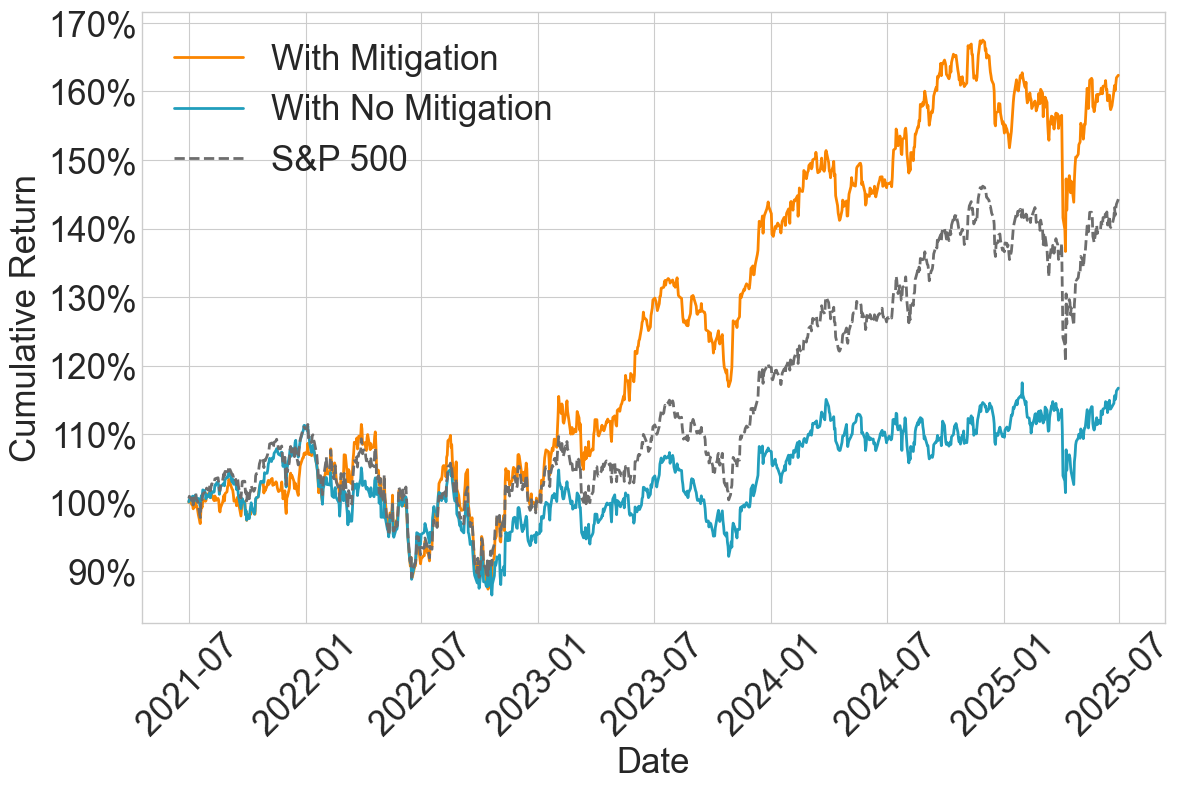

In [42]:
portfolios = construct_portfolio(*load_data(), split_num=20, bool_print=False, action=0.2, no_action=0.7)  # Adjust split_num as needed
analyze_and_visualize(portfolios, end_date='2028-07-05')

In [6]:
a_2021 = ['RSG', 'CAG', 'TMUS', 'INCY', 'PPG', 'KMB', 'ON', 'ALB', 'ED', 'CHRW', 'ABT', 'ROL', 'POOL', 'AWK', 'CB', 'AXON', 'CTAS', 'EW', 'AMZN', 'VRSK']
a_2022 = ['ERIE', 'CMCSA', 'CPAY', 'EL', 'FITB', 'SPG', 'TPL', 'MCK', 'JCI', 'VRSN', 'HSY', 'CHRW', 'CTAS', 'DAY', 'FFIV', 'CMI', 'AMZN', 'AWK', 'VRSK', 'CPRT']
a_2023 = ['AEE', 'RSG', 'BA', 'DAY', 'PRU', 'FSLR', 'KMB', 'ESS', 'HSY', 'CBRE', 'VMC', 'DRI', 'AZO', 'LHX', 'CMI', 'ROK', 'FFIV', 'VRSK', 'EL', 'HAL']
a_2024 = ['RSG', 'CAG', 'TMUS', 'INCY', 'PPG', 'KMB', 'ON', 'ALB', 'ED', 'CHRW', 'ABT', 'ROL', 'POOL', 'AWK', 'CB', 'AXON', 'CTAS', 'EW', 'AMZN', 'VRSK']
